# Week 2 - Commit 1
## Feature Engineering: Tenure & Monthly Charges Features

### Objective
To create new features from customer tenure and monthly charges that can improve churn prediction performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import pandas as pd

df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [4]:
df['Tenure_Group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=[
        'New Customer',
        'Regular Customer',
        'Loyal Customer',
        'Long-Term Customer'
    ]
)

df[['tenure', 'Tenure_Group']].head()

,tenure,Tenure_Group
0,1,New Customer
1,34,Loyal Customer
2,2,New Customer
3,45,Loyal Customer
4,2,New Customer


In [5]:
df['MonthlyCharge_Category'] = pd.cut(
    df['MonthlyCharges'],
    bins=[0, 35, 70, 120],
    labels=['Low', 'Medium', 'High']
)

df[['MonthlyCharges', 'MonthlyCharge_Category']].head()

,MonthlyCharges,MonthlyCharge_Category
0,29.85,Low
1,56.95,Medium
2,53.85,Medium
3,42.30,Medium
4,70.70,High


In [6]:
df['Tenure_Group'].value_counts()

Tenure_Group
Long-Term Customer    2239
New Customer          2175
Loyal Customer        1594
Regular Customer      1024
Name: count, dtype: int64

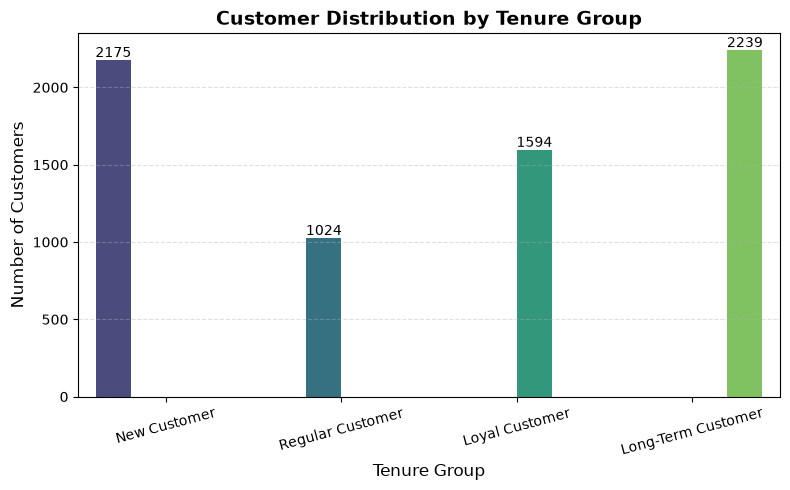

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import os



plt.figure(figsize=(8,5))

ax = sns.countplot(
    x='Tenure_Group',
    data=df,
    hue='Tenure_Group',
    palette='viridis',
    legend=False
)

plt.title('Customer Distribution by Tenure Group',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Tenure Group', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Add values on bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()



plt.show()



In [8]:
df['MonthlyCharge_Category'].value_counts()

MonthlyCharge_Category
High      3583
Low       1735
Medium    1725
Name: count, dtype: int64

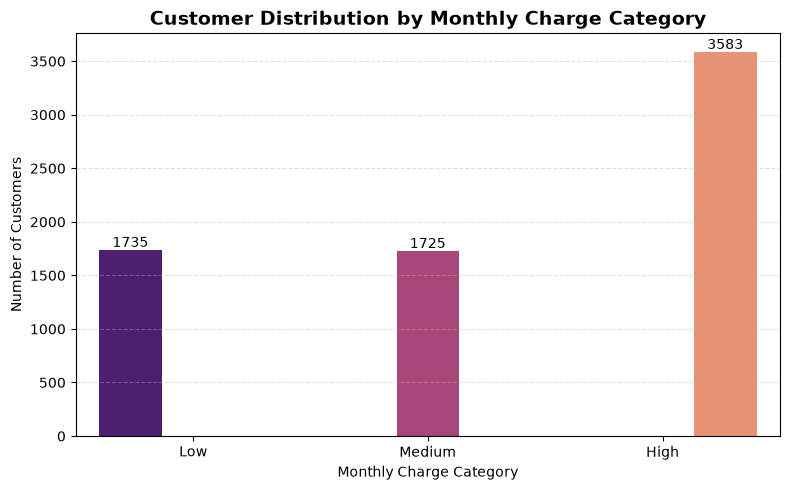

In [9]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    x='MonthlyCharge_Category',
    data=df,
    hue='MonthlyCharge_Category',
    palette='magma',
    legend=False
)

plt.title('Customer Distribution by Monthly Charge Category',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Monthly Charge Category')
plt.ylabel('Number of Customers')

plt.grid(axis='y', linestyle='--', alpha=0.4)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.tight_layout()



plt.show()



## Conclusion

Successfully created tenure-based and monthly charge-based features. These engineered features will be used in subsequent predictive modeling tasks such as Logistic Regression, Random Forest, and XGBoost.

# Week 2 - Commit 2

# Advanced Feature Engineering

## Objective

To create advanced customer behavior features such as Customer Engagement Level, Total Services, and Internet Service indicators that improve churn prediction and customer segmentation.


In [10]:
service_columns = [
    'PhoneService',
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

df['TotalServices'] = (
    df[service_columns]
    .replace({'Yes':1, 'No':0, 'No internet service':0, 'No phone service':0})
    .sum(axis=1)
)

print("TotalServices feature created")

TotalServices feature created


In [11]:
df['InternetServiceFlag'] = df['InternetService'].apply(
    lambda x: 0 if x == 'No' else 1
)

print("InternetServiceFlag created")

InternetServiceFlag created


In [12]:
df['SecuritySupport'] = (
    (df['OnlineSecurity'] == 'Yes') &
    (df['TechSupport'] == 'Yes')
).astype(int)

print("SecuritySupport feature created")

SecuritySupport feature created


In [13]:
print(df[['TotalServices',
          'InternetServiceFlag',
          'SecuritySupport']].head())

  TotalServices  InternetServiceFlag  SecuritySupport
0             1                    1                0
1             3                    1                0
2             3                    1                0
3             3                    1                1
4             1                    1                0


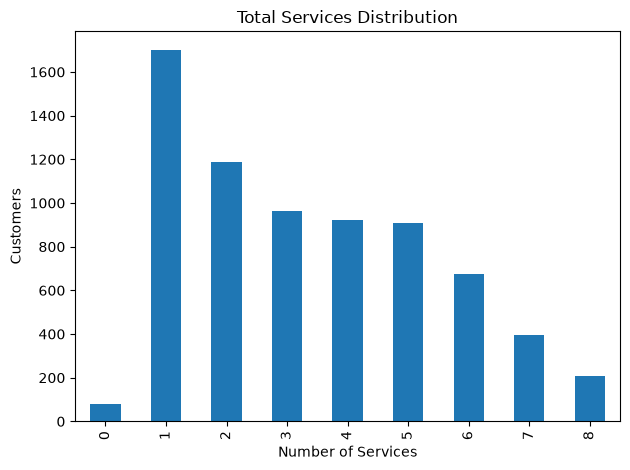

In [14]:
import matplotlib.pyplot as plt

df['TotalServices'].value_counts().sort_index().plot(
    kind='bar'
)

plt.title("Total Services Distribution")
plt.xlabel("Number of Services")
plt.ylabel("Customers")
plt.tight_layout()

plt.savefig("../screenshots/week2_commit2_total_services_distribution.png")
plt.show()

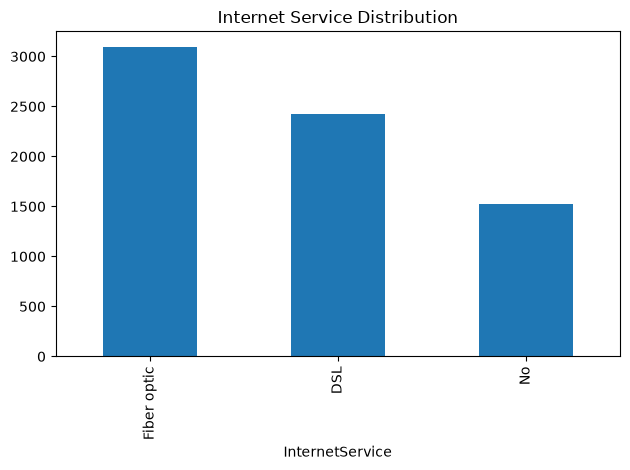

In [15]:
df['InternetService'].value_counts().plot(
    kind='bar'
)

plt.title("Internet Service Distribution")
plt.tight_layout()

plt.savefig("../screenshots/week2_commit2_internet_service_distribution.png")
plt.show()

In [16]:
df['PremiumCustomerScore'] = (
    (df['MonthlyCharges'] > df['MonthlyCharges'].median()) &
    (df['TotalServices'] >= 4)
).astype(int)

print("PremiumCustomerScore created")

PremiumCustomerScore created


In [17]:
df['SecurityAwarenessScore'] = (
    (df['OnlineSecurity'] == 'Yes').astype(int) +
    (df['OnlineBackup'] == 'Yes').astype(int) +
    (df['DeviceProtection'] == 'Yes').astype(int)
)

print("SecurityAwarenessScore created")

SecurityAwarenessScore created


In [18]:
df['EntertainmentScore'] = (
    (df['StreamingTV'] == 'Yes').astype(int) +
    (df['StreamingMovies'] == 'Yes').astype(int)
)

print("EntertainmentScore created")

EntertainmentScore created


In [19]:
service_columns = [
    'PhoneService',
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

df['ServiceAdoptionScore'] = (
    df[service_columns]
    .replace({
        'Yes': 1,
        'No': 0,
        'No internet service': 0,
        'No phone service': 0
    })
    .sum(axis=1)
)

print("ServiceAdoptionScore created")

ServiceAdoptionScore created


In [20]:
def engagement(score):
    if score <= 2:
        return "Low"
    elif score <= 5:
        return "Medium"
    else:
        return "High"

df["CustomerEngagementLevel"] = df["ServiceAdoptionScore"].apply(engagement)

print("CustomerEngagementLevel created")

CustomerEngagementLevel created


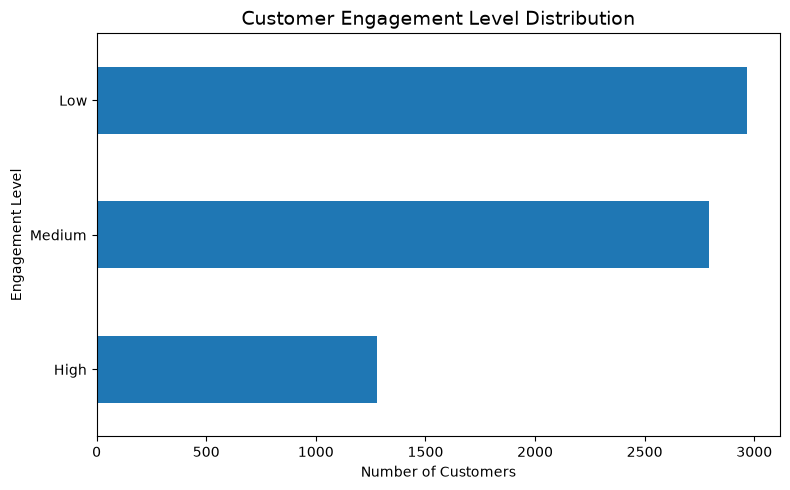

In [21]:
import matplotlib.pyplot as plt

engagement_counts = df['CustomerEngagementLevel'].value_counts()

plt.figure(figsize=(8,5))
engagement_counts.sort_values().plot(kind='barh')

plt.title('Customer Engagement Level Distribution', fontsize=14)
plt.xlabel('Number of Customers')
plt.ylabel('Engagement Level')

plt.tight_layout()
plt.savefig('../screenshots/week2_commit2_customer_engagement_barh.png')
plt.show()

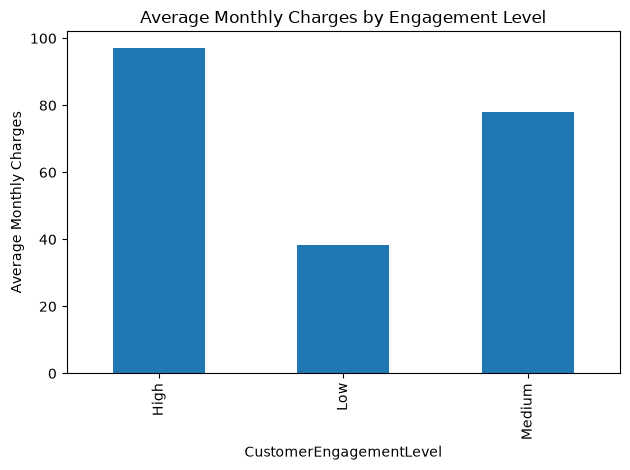

In [22]:
df.groupby('CustomerEngagementLevel')['MonthlyCharges'].mean().plot(
    kind='bar'
)

plt.title("Average Monthly Charges by Engagement Level")
plt.ylabel("Average Monthly Charges")

plt.tight_layout()

plt.savefig("../screenshots/week2_commit2_engagement_vs_charges.png")
plt.show()

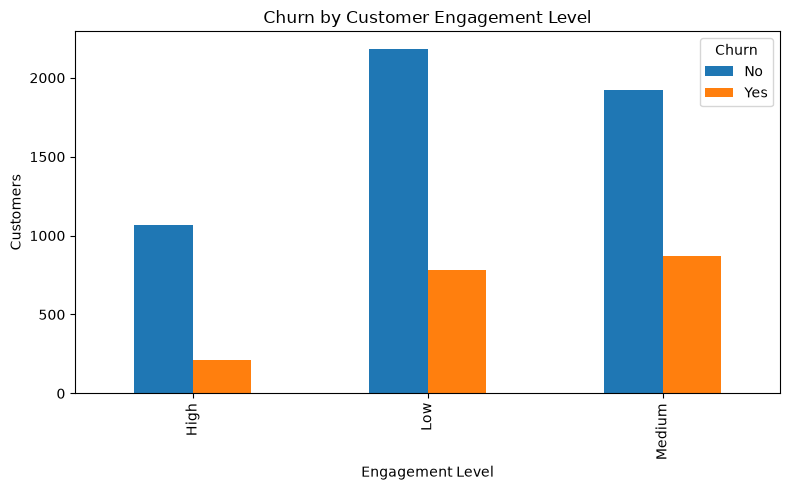

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

pd.crosstab(
    df['CustomerEngagementLevel'],
    df['Churn']
).plot(kind='bar', figsize=(8,5))

plt.title('Churn by Customer Engagement Level')
plt.xlabel('Engagement Level')
plt.ylabel('Customers')

plt.tight_layout()
plt.savefig('../screenshots/week2_commit2_churn_vs_engagement.png')
plt.show()

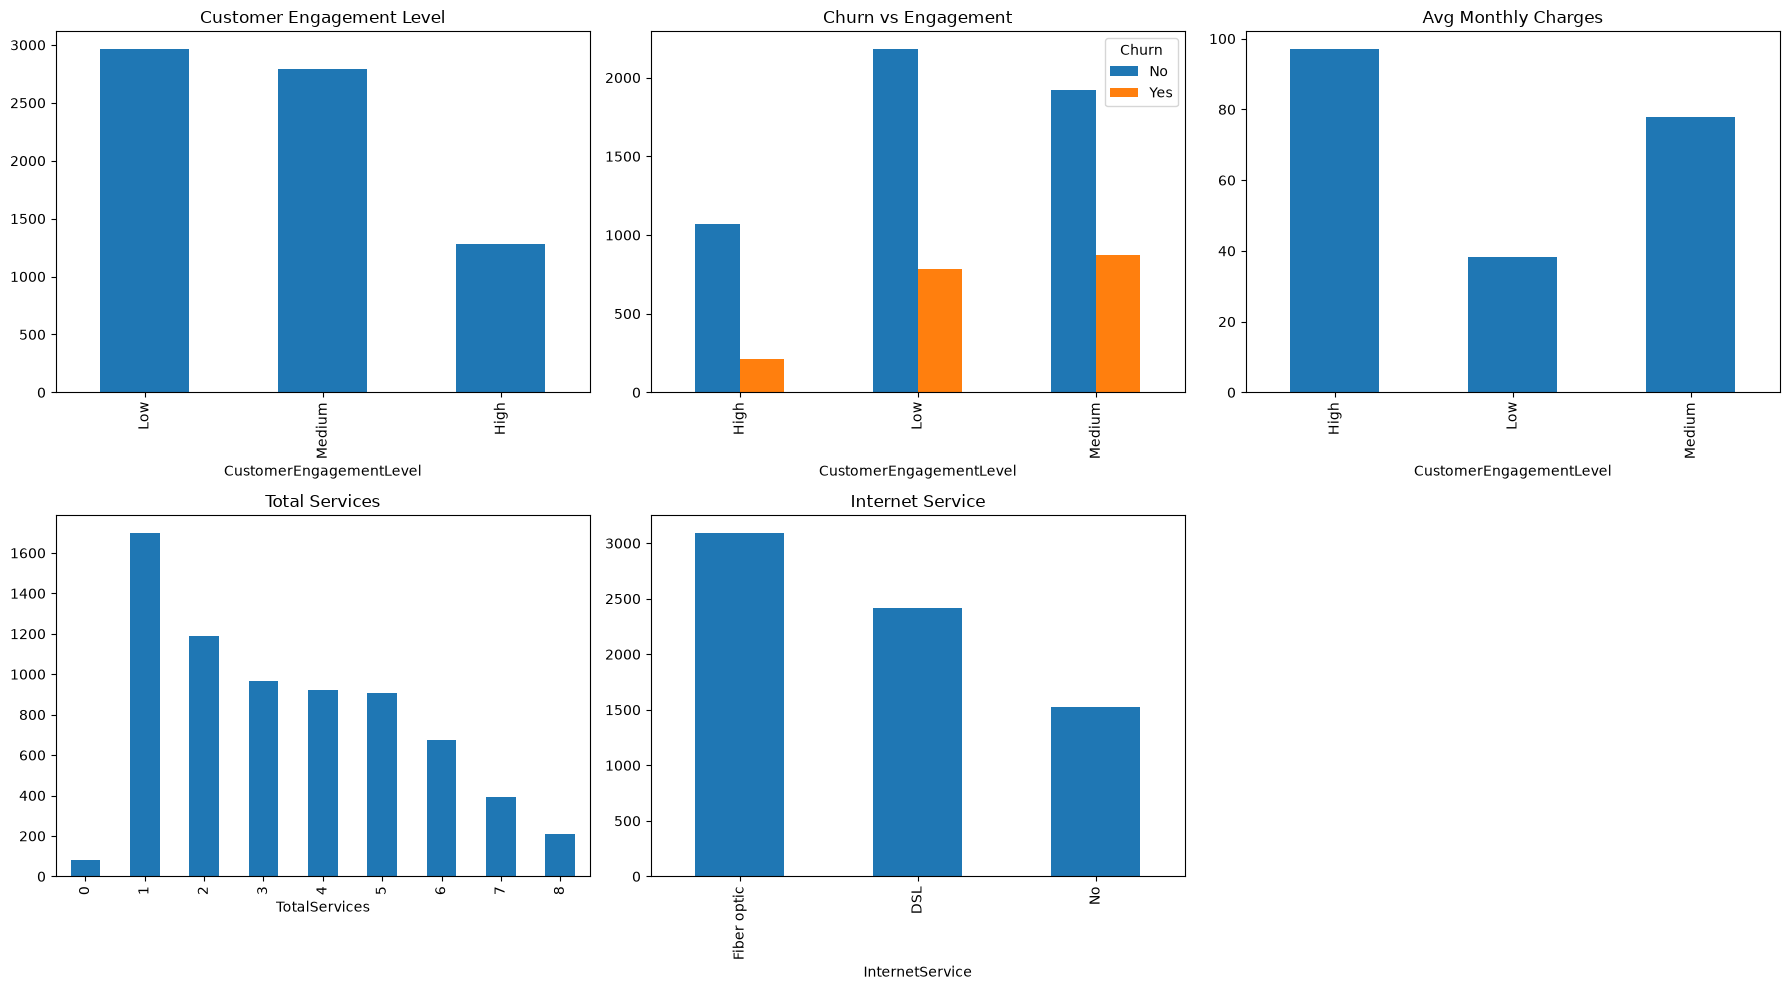

In [24]:
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(18,10))

# Graph 1
plt.subplot(2,3,1)
df['CustomerEngagementLevel'].value_counts().plot(kind='bar')
plt.title('Customer Engagement Level')

# Graph 2
plt.subplot(2,3,2)
pd.crosstab(
    df['CustomerEngagementLevel'],
    df['Churn']
).plot(kind='bar', ax=plt.gca())
plt.title('Churn vs Engagement')

# Graph 3
plt.subplot(2,3,3)
df.groupby('CustomerEngagementLevel')['MonthlyCharges'].mean().plot(kind='bar')
plt.title('Avg Monthly Charges')

# Graph 4
plt.subplot(2,3,4)
df['TotalServices'].value_counts().sort_index().plot(kind='bar')
plt.title('Total Services')

# Graph 5
plt.subplot(2,3,5)
df['InternetService'].value_counts().plot(kind='bar')
plt.title('Internet Service')

plt.tight_layout()

plt.savefig("../screenshots/week2_commit2_dashboard.png")
plt.show()

In [25]:
df.to_csv(
    "../data/telco_feature_engineered_commit2.csv",
    index=False
)

print("Feature engineered dataset saved successfully")

Feature engineered dataset saved successfully


## Conclusion

Advanced feature engineering was successfully completed by creating meaningful customer behavior features such as Customer Engagement Level and Total Services. These new features provide deeper insights into customer engagement patterns and service usage, helping improve the performance and interpretability of future churn prediction models.

# Week 2 Day 3 - Customer Behavior Feature Engineering

## Objective
Create customer behavior-based features to identify premium, long-term, and high-value customers and analyze contract-related churn risk.

In [26]:
import pandas as pd

df = pd.read_csv("../data/telco_feature_engineered_commit2.csv")

In [27]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,Tenure_Group,MonthlyCharge_Category,TotalServices,InternetServiceFlag,SecuritySupport,PremiumCustomerScore,SecurityAwarenessScore,EntertainmentScore,ServiceAdoptionScore,CustomerEngagementLevel
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,New Customer,Low,1,1,0,0,1,0,1,Low
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Loyal Customer,Medium,3,1,0,0,2,0,3,Medium
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,New Customer,Medium,3,1,0,0,2,0,3,Medium
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Loyal Customer,Medium,3,1,1,0,2,0,3,Medium
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,New Customer,High,1,1,0,0,0,0,1,Low


In [28]:
df['PremiumCustomerScore'] = (
    (df['MonthlyCharges'] > df['MonthlyCharges'].median()) &
    (df['TotalServices'] >= 4)
).astype(int)

In [29]:
df['LongTermCustomer'] = (
    df['tenure'] >= 24
).astype(int)

In [30]:
df['HighValueCustomer'] = (
    (df['MonthlyCharges'] > 70) &
    (df['tenure'] > 12)
).astype(int)

In [31]:
def contract_risk(contract):
    if contract == "Month-to-month":
        return "High Risk"
    elif contract == "One year":
        return "Medium Risk"
    else:
        return "Low Risk"

df['ContractRiskLevel'] = df['Contract'].apply(contract_risk)

In [32]:
print("High Value Customer")
print(df['HighValueCustomer'].value_counts())

print("\nContract Risk Level")
print(df['ContractRiskLevel'].value_counts())

print("\nLong Term Customer")
print(df['LongTermCustomer'].value_counts())

High Value Customer
HighValueCustomer
0    4335
1    2708
Name: count, dtype: int64

Contract Risk Level
ContractRiskLevel
High Risk      3875
Low Risk       1695
Medium Risk    1473
Name: count, dtype: int64

Long Term Customer
LongTermCustomer
1    3927
0    3116
Name: count, dtype: int64


In [33]:
print("\nPremium Customer Score")
print(df['PremiumCustomerScore'].value_counts())


Premium Customer Score
PremiumCustomerScore
0    4549
1    2494
Name: count, dtype: int64


In [34]:
df[['PremiumCustomerScore',
    'HighValueCustomer',
    'LongTermCustomer',
    'ContractRiskLevel']].head(10)

,PremiumCustomerScore,HighValueCustomer,LongTermCustomer,ContractRiskLevel
0,0,0,0,High Risk
1,0,0,1,Medium Risk
2,0,0,0,High Risk
3,0,0,1,Medium Risk
4,0,0,0,High Risk
5,1,0,0,High Risk
6,1,1,0,High Risk
7,0,0,0,High Risk
8,1,1,1,High Risk
9,0,0,1,Medium Risk


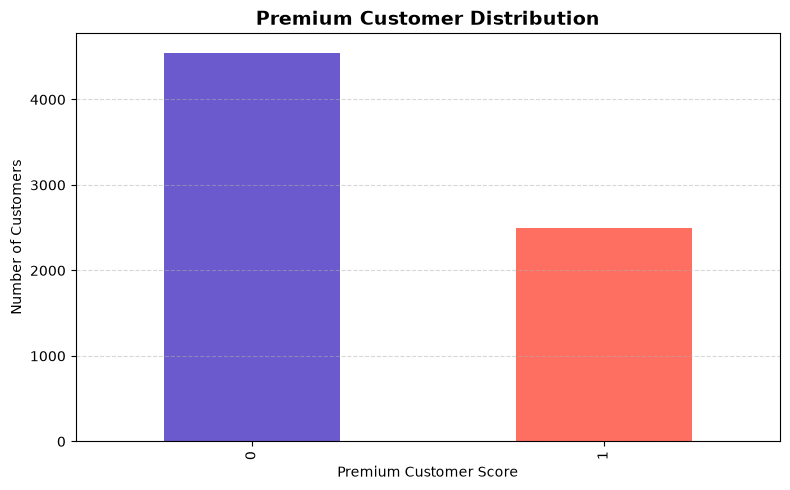

In [35]:
import matplotlib.pyplot as plt

premium_counts = df['PremiumCustomerScore'].value_counts()

plt.figure(figsize=(8,5))
premium_counts.plot(
    kind='bar',
    color=['#6A5ACD', '#FF6F61']
)

plt.title('Premium Customer Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Premium Customer Score')
plt.ylabel('Number of Customers')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(
    '../screenshots/week2_commit3_premium_customer_distribution.png'
)
plt.show()

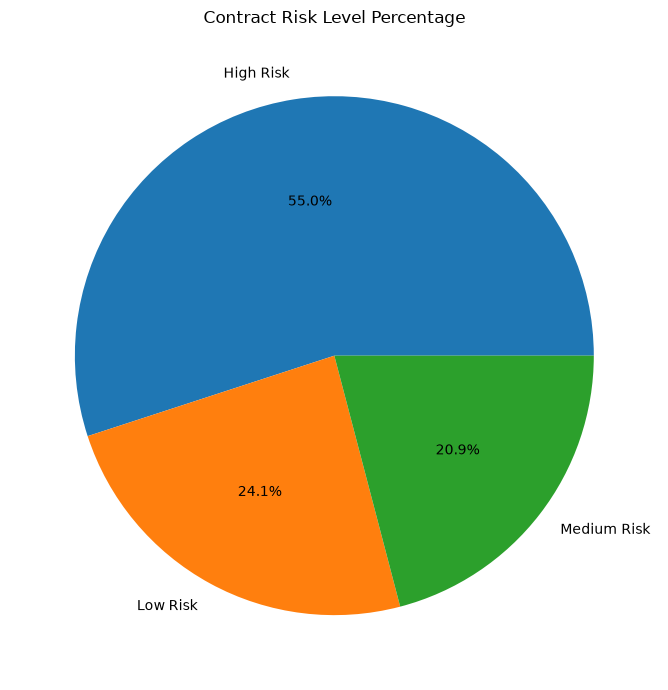

In [36]:
plt.figure(figsize=(7,7))
df['ContractRiskLevel'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Contract Risk Level Percentage')
plt.ylabel('')
plt.tight_layout()
plt.savefig(
    '../screenshots/week2_commit3_contract_risk_pie.png'
)
plt.show()

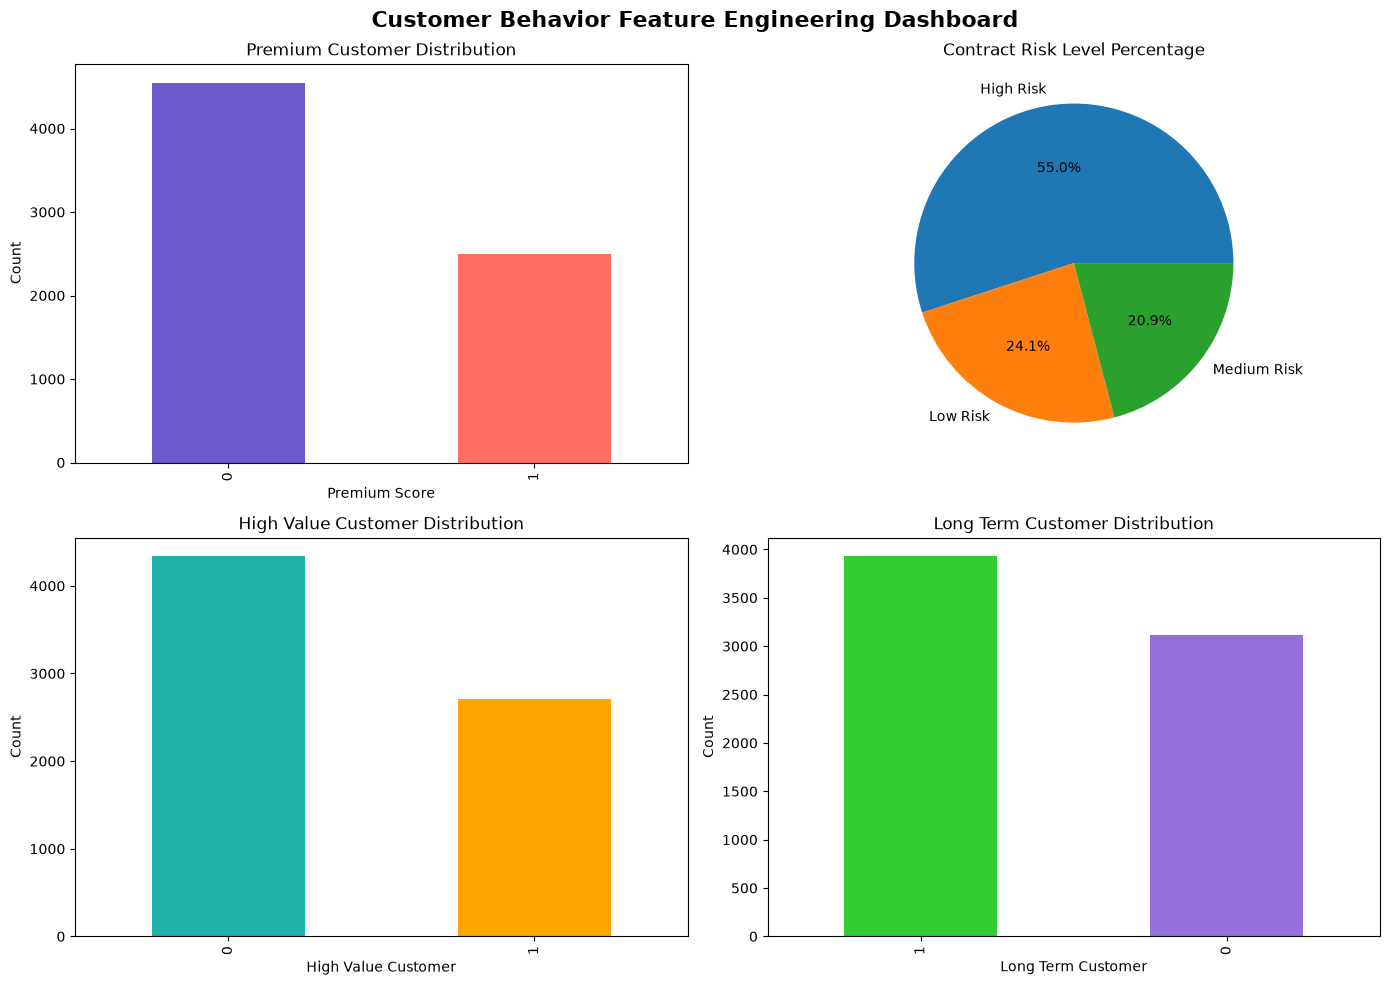

In [37]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Premium Customer Distribution (Bar Chart)
df['PremiumCustomerScore'].value_counts().plot(
    kind='bar',
    ax=axes[0,0],
    color=['#6A5ACD','#FF6F61']
)
axes[0,0].set_title('Premium Customer Distribution')
axes[0,0].set_xlabel('Premium Score')
axes[0,0].set_ylabel('Count')

# 2. Contract Risk Level Percentage (Pie Chart)
df['ContractRiskLevel'].value_counts().plot(
    kind='pie',
    ax=axes[0,1],
    autopct='%1.1f%%'
)
axes[0,1].set_title('Contract Risk Level Percentage')
axes[0,1].set_ylabel('')

# 3. High Value Customer Distribution (Bar Chart)
df['HighValueCustomer'].value_counts().plot(
    kind='bar',
    ax=axes[1,0],
    color=['#20B2AA','#FFA500']
)
axes[1,0].set_title('High Value Customer Distribution')
axes[1,0].set_xlabel('High Value Customer')
axes[1,0].set_ylabel('Count')

# 4. Long Term Customer Distribution (Bar Chart)
df['LongTermCustomer'].value_counts().plot(
    kind='bar',
    ax=axes[1,1],
    color=['#32CD32','#9370DB']
)
axes[1,1].set_title('Long Term Customer Distribution')
axes[1,1].set_xlabel('Long Term Customer')
axes[1,1].set_ylabel('Count')

plt.suptitle(
    'Customer Behavior Feature Engineering Dashboard',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('../screenshots/week2_commit3_dashboard.png')
plt.show()

In [38]:
df.to_csv(
    "../data/telco_feature_engineered_commit3.csv",
    index=False
)

## Conclusion

Customer behavior-based feature engineering was successfully completed on the Telco Customer Churn dataset. New features including PremiumCustomerScore, HighValueCustomer, LongTermCustomer, and ContractRiskLevel were created to capture customer value, loyalty, and risk patterns. The dashboard visualizations provided meaningful insights into customer segments and contract-related behavior. These engineered features enhance the dataset and provide a stronger foundation for customer churn prediction and business decision-making in the next phase of the project.

# Week 2 Day 4 - Logistic Regression Model Training

## Objective

The objective of this task is to train a Logistic Regression model using the feature-engineered Telco Customer Churn dataset. The model will be used to predict customer churn based on customer attributes and engineered features.

### Goals

- Prepare the feature-engineered dataset for machine learning.
- Define the target variable for customer churn prediction.
- Split the dataset into training and testing sets.
- Train a Logistic Regression classification model.
- Generate churn predictions for the test data.
- Establish a baseline model for customer churn prediction.

In [39]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [40]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles/folders available:")
print(os.listdir())

Current working directory:
c:\Users\Afreen\OneDrive\Desktop\zaalima-data-analytic\scripts

Files/folders available:
['data_loader.py', 'feature_engineering.ipynb']


In [41]:
# Load the final feature-engineered dataset from Day 3
df = pd.read_csv("../data/telco_feature_engineered_commit3.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (7043, 34)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,InternetServiceFlag,SecuritySupport,PremiumCustomerScore,SecurityAwarenessScore,EntertainmentScore,ServiceAdoptionScore,CustomerEngagementLevel,LongTermCustomer,HighValueCustomer,ContractRiskLevel
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,1,0,0,1,0,1,Low,0,0,High Risk
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,1,0,0,2,0,3,Medium,1,0,Medium Risk
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,1,0,0,2,0,3,Medium,0,0,High Risk
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,1,1,0,2,0,3,Medium,1,0,Medium Risk
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,1,0,0,0,0,1,Low,0,0,High Risk


In [42]:
# Check the target variable
print("Churn value counts:")
print(df["Churn"].value_counts())

print("\nChurn data types:")
print(df["Churn"].dtype)

Churn value counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn data types:
str


In [43]:
# Convert Churn into a binary target variable
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

print("Churn values after encoding:")
print(df["Churn"].value_counts())

Churn values after encoding:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [44]:
# Separate features and target variable

X = df.drop(columns=["Churn"])
y = df["Churn"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7043, 33)
Target shape: (7043,)


In [45]:
# Identify categorical and numerical features

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

print("\nNumber of categorical columns:", len(categorical_cols))
print("Number of numerical columns:", len(numerical_cols))

Categorical columns:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Tenure_Group', 'MonthlyCharge_Category', 'CustomerEngagementLevel', 'ContractRiskLevel']

Number of categorical columns: 21
Number of numerical columns: 12


C:\Users\Afreen\AppData\Local\Temp\ipykernel_9484\1582259082.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()


In [46]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Create preprocessing transformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [47]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (5634, 33)
Testing features: (1409, 33)
Training target: (5634,)
Testing target: (1409,)


In [48]:
# Apply preprocessing to training and testing data

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training data shape:", X_train_processed.shape)
print("Processed testing data shape:", X_test_processed.shape)

Processed training data shape: (5634, 10977)
Processed testing data shape: (1409, 10977)


In [49]:
# Train Logistic Regression model

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_processed, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [50]:
# Generate predictions on the test data

y_pred = logistic_model.predict(X_test_processed)

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred))

Predictions generated successfully.
Number of predictions: 1409


In [51]:
# Calculate Logistic Regression accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Logistic Regression Accuracy:", round(accuracy, 4))
print("Accuracy Percentage:", round(accuracy * 100, 2), "%")

Logistic Regression Accuracy: 0.7949
Accuracy Percentage: 79.49 %


In [52]:
# Generate classification report

print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.64      0.51      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.79      1409



In [53]:
# Generate confusion matrix

cm = confusion_matrix(y_test, y_pred)

print("Logistic Regression Confusion Matrix:")
print(cm)

Logistic Regression Confusion Matrix:
[[929 106]
 [183 191]]


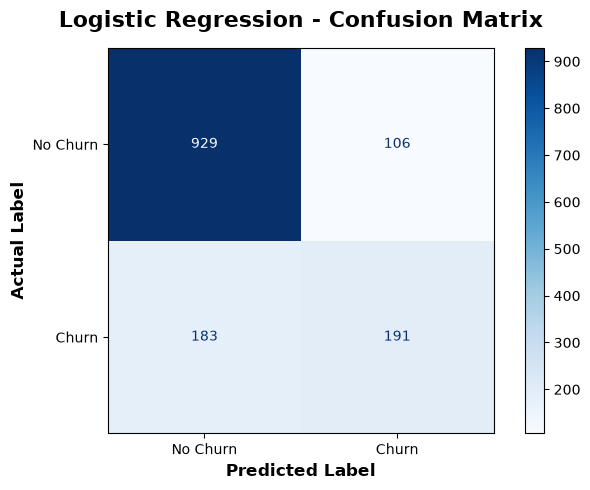

In [54]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Plot professional confusion matrix
fig, ax = plt.subplots(figsize=(7, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=True
)

ax.set_title(
    "Logistic Regression - Confusion Matrix",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Predicted Label", fontsize=12, fontweight="bold")
ax.set_ylabel("Actual Label", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig(
    '../screenshots/week2_commit4_Confusion Matrix.png')
plt.show()

In [55]:
import joblib

# Save the trained Logistic Regression model
joblib.dump(logistic_model, "../data/logistic_regression_model.pkl")

print("Logistic Regression model saved successfully.")

Logistic Regression model saved successfully.


In [56]:
# Save the preprocessing pipeline
joblib.dump(preprocessor, "../data/logistic_regression_preprocessor.pkl")

print("Preprocessing pipeline saved successfully.")

Preprocessing pipeline saved successfully.


## Conclusion

The Logistic Regression model was successfully trained using the feature-engineered Telco Customer Churn dataset. After preprocessing the categorical and numerical features, the model achieved an accuracy of **79.49%** on the test dataset. The classification report and confusion matrix provided insights into the model's performance in predicting customer churn. The trained model and preprocessing pipeline were also saved for future use and evaluation.





# Week 2 Day 5 - Logistic Regression Evaluation & Results

## Objective

The objective of this task is to evaluate the performance of the trained Logistic Regression model using various evaluation metrics and visualization techniques.

### Goals

- Evaluate model performance using classification metrics.
- Analyze the confusion matrix.
- Generate ROC Curve and AUC Score.
- Interpret the model results.
- Document key findings and conclusions.

In [57]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

import matplotlib.pyplot as plt
import numpy as np

In [58]:
print("Logistic Regression Accuracy:", round(accuracy,4))
print("Accuracy Percentage:", round(accuracy*100,2), "%")

Logistic Regression Accuracy: 0.7949
Accuracy Percentage: 79.49 %


In [59]:
# Calculate evaluation metrics

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Accuracy : 0.7949
Precision: 0.6431
Recall   : 0.5107
F1 Score : 0.5693


In [60]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

In [61]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [62]:
X = X.drop("customerID", axis=1)

In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [64]:
X_train.select_dtypes(include=['object']).columns

C:\Users\Afreen\AppData\Local\Temp\ipykernel_9484\1043803422.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X_train.select_dtypes(include=['object']).columns


Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Tenure_Group',
       'MonthlyCharge_Category', 'CustomerEngagementLevel',
       'ContractRiskLevel'],
      dtype='str')

In [65]:

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in X.select_dtypes(include=['object']).columns:
    X[col] = le.fit_transform(X[col].astype(str))



C:\Users\Afreen\AppData\Local\Temp\ipykernel_9484\3129242868.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X.select_dtypes(include=['object']).columns:


In [66]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [67]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


c:\Users\Afreen\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [68]:
y_pred = model.predict(X_test)

In [69]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.53      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [70]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[928 107]
 [176 198]]


In [71]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", auc)

ROC-AUC Score: 0.8408277144850035


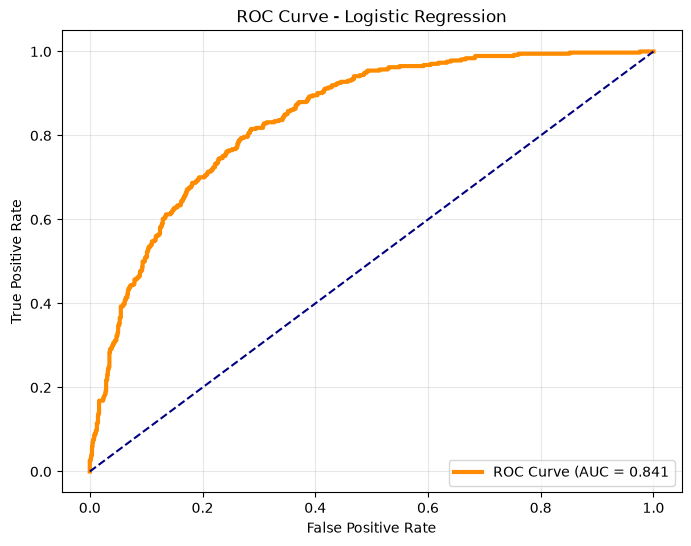

In [72]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', linewidth=3,
         label=f'ROC Curve (AUC = {auc:.3f}')
plt.plot([0,1], [0,1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

<Figure size 600x500 with 0 Axes>

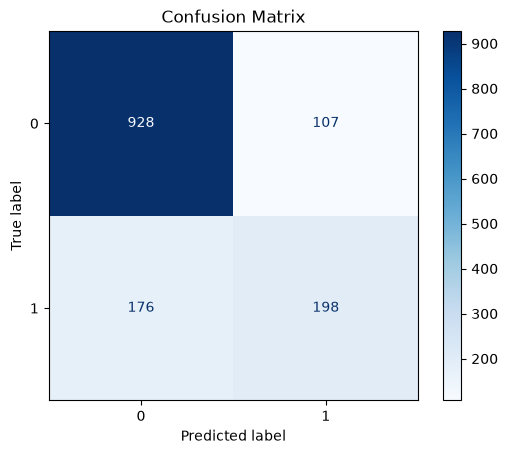

In [73]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

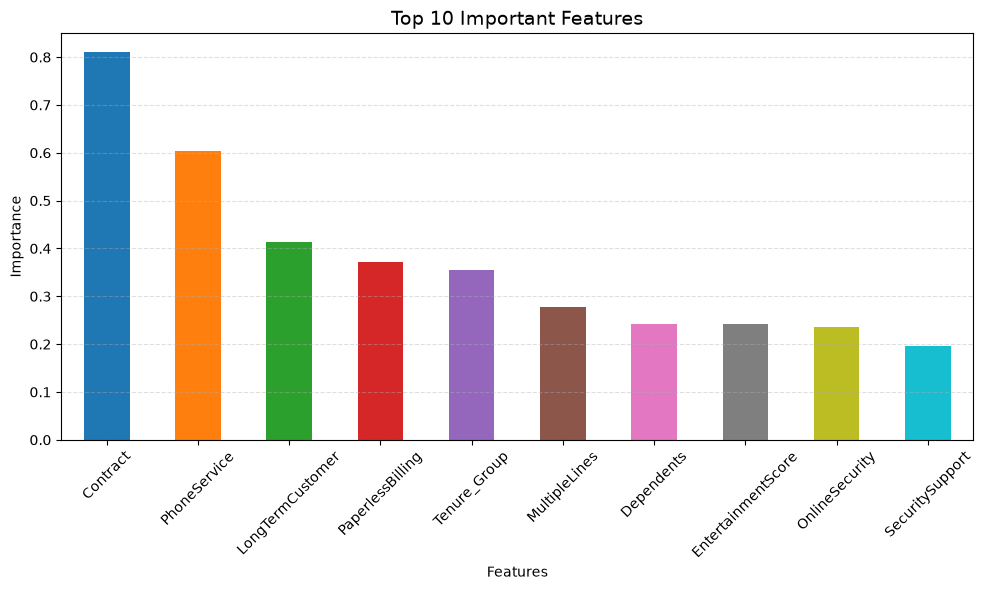

In [74]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    abs(model.coef_[0]),
    index=X_train.columns
).sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
importance.plot(
    kind='bar',
    color=['#1f77b4','#ff7f0e','#2ca02c','#d62728',
           '#9467bd','#8c564b','#e377c2','#7f7f7f',
           '#bcbd22','#17becf']
)

plt.title('Top 10 Important Features', fontsize=14)
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

Dashboard saved successfully!


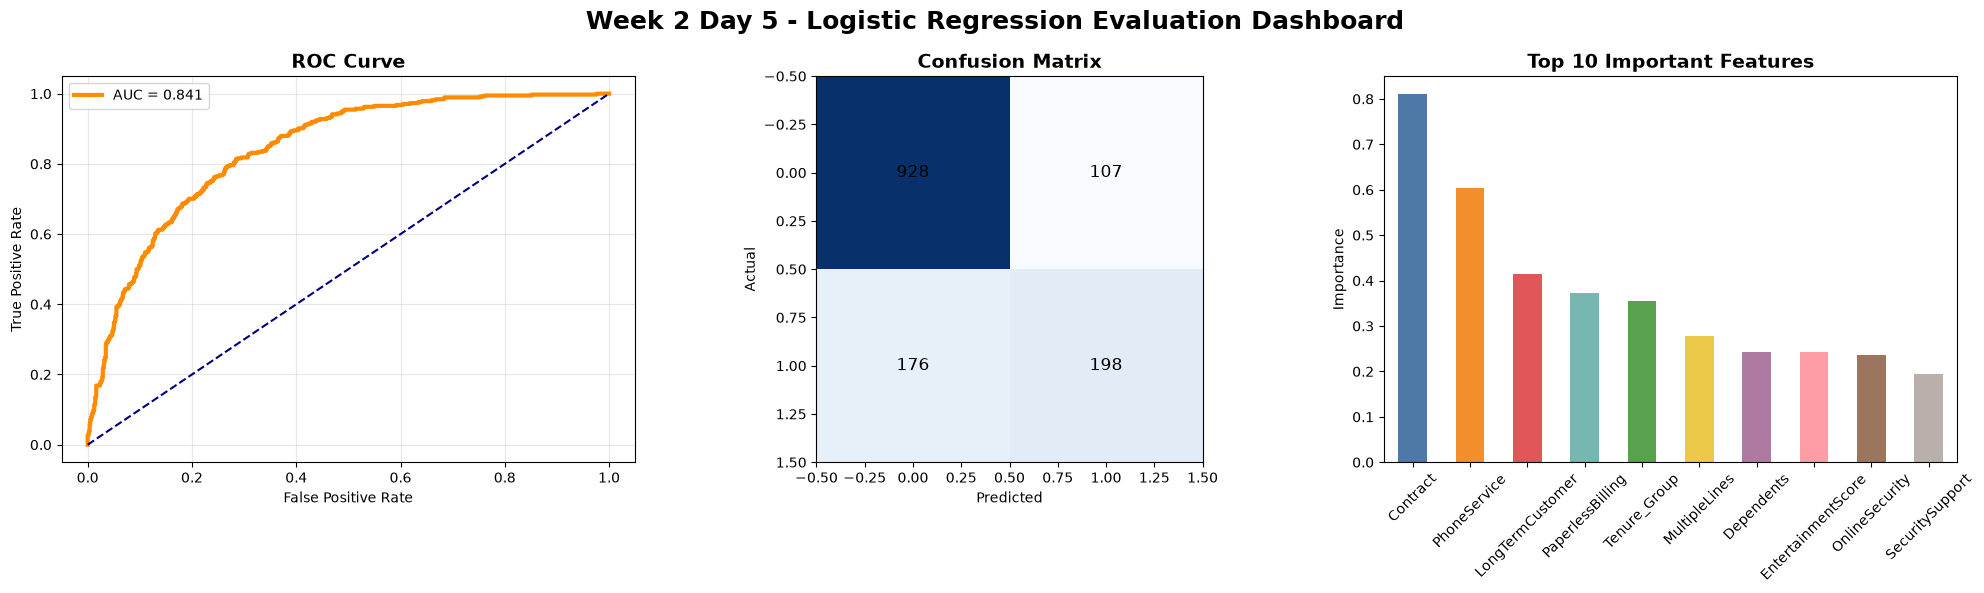

In [75]:
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
import pandas as pd
import matplotlib.pyplot as plt
import os

# Create screenshots folder if it doesn't exist
os.makedirs("../screenshots", exist_ok=True)

# Create Dashboard
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# =====================================
# 1. ROC Curve
# =====================================
y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

axes[0].plot(
    fpr,
    tpr,
    color="darkorange",
    linewidth=3,
    label=f"AUC = {auc:.3f}"
)

axes[0].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="navy"
)

axes[0].set_title(
    "ROC Curve",
    fontsize=14,
    fontweight="bold"
)

axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# =====================================
# 2. Confusion Matrix
# =====================================
cm = confusion_matrix(y_test, y_pred)

im = axes[1].imshow(cm, cmap="Blues")

axes[1].set_title(
    "Confusion Matrix",
    fontsize=14,
    fontweight="bold"
)

axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[1].text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=12,
            color="black"
        )

# =====================================
# 3. Feature Importance
# =====================================
importance = pd.Series(
    abs(model.coef_[0]),
    index=X_train.columns
).sort_values(ascending=False).head(10)

importance.plot(
    kind="bar",
    ax=axes[2],
    color=[
        "#4e79a7",
        "#f28e2b",
        "#e15759",
        "#76b7b2",
        "#59a14f",
        "#edc949",
        "#af7aa1",
        "#ff9da7",
        "#9c755f",
        "#bab0ab"
    ]
)

axes[2].set_title(
    "Top 10 Important Features",
    fontsize=14,
    fontweight="bold"
)

axes[2].set_ylabel("Importance")
axes[2].tick_params(axis="x", rotation=45)

# =====================================
# Dashboard Title
# =====================================
plt.suptitle(
    "Week 2 Day 5 - Logistic Regression Evaluation Dashboard",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

# =====================================
# Save Dashboard
# =====================================
plt.savefig(
    "../screenshots/week2_day5_evaluation_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

print("Dashboard saved successfully!")

plt.show()

# Conclusion

The Logistic Regression model was successfully trained and evaluated on the Telco Customer Churn dataset. Various evaluation metrics, including Accuracy Score, Classification Report, Confusion Matrix, ROC Curve, and ROC-AUC Score, were used to assess model performance.

The model achieved a ROC-AUC score of approximately 0.84, indicating good predictive capability in distinguishing churn and non-churn customers. The confusion matrix and ROC Curve further confirmed the effectiveness of the model.

Overall, the model demonstrates strong performance and can be used as a baseline solution for customer churn prediction and business decision-making.

# Week 3 - Commit 1

## Topic
LTV Target Variable Preparation and Regression Dataset Creation

## Objective
- Understand the concept of Customer Lifetime Value (LTV).
- Prepare the dataset for regression-based LTV prediction.
- Create the LTV target variable using customer-related features.
- Clean and preprocess the dataset by handling missing values and data type issues.
- Select relevant features for LTV prediction.
- Encode categorical variables into a machine-learning-friendly format.
- Separate the dataset into features (X) and target variable (y).



In [76]:
import pandas as pd
import numpy as np

In [77]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(df.head())
print(df.shape)

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [78]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [79]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

C:\Users\Afreen\AppData\Local\Temp\ipykernel_9484\3692201336.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [80]:
df["LTV"] = df["MonthlyCharges"] * df["tenure"]

In [81]:
print(df[["MonthlyCharges", "tenure", "LTV"]].head())

   MonthlyCharges  tenure      LTV
0           29.85       1    29.85
1           56.95      34  1936.30
2           53.85       2   107.70
3           42.30      45  1903.50
4           70.70       2   141.40


In [82]:
X = df.drop(["customerID", "Churn", "LTV"], axis=1)

y = df["LTV"]

In [83]:
print(X.head())
print(y.head())

   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   
3    Male              0      No         No      45           No   
4  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No          No          No              No  Month-to-month   
1              Yes          No  

In [84]:
X = pd.get_dummies(X, drop_first=True)

In [85]:
print(X.shape)

(7043, 30)


In [86]:
prepared_data = X.copy()
prepared_data["LTV"] = y

prepared_data.to_csv("../data/ltv_prepared_dataset.csv", index=False)

print("Dataset prepared successfully!")

Dataset prepared successfully!


In [87]:
print("Feature Shape:", X.shape)
print("Target Shape:",y.shape)
print(prepared_data.head())

Feature Shape: (7043, 30)
Target Shape: (7043,)
   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
0              0       1           29.85         29.85        False   
1              0      34           56.95       1889.50         True   
2              0       2           53.85        108.15         True   
3              0      45           42.30       1840.75         True   
4              0       2           70.70        151.65        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False              True   

   MultipleLines_No phone service  MultipleLines_Yes  ...  StreamingTV_Yes  \
0                            True              False  ...            False   
1                           False              False  ..

## Conclusion

In this commit, the dataset was successfully prepared for Customer Lifetime Value (LTV) prediction. Data preprocessing steps were performed to ensure data quality, including handling missing values and converting data types where necessary. A new LTV target variable was created using customer tenure and monthly charges. Relevant features were selected and categorical variables were encoded to make the dataset suitable for machine learning algorithms. Finally, the prepared regression dataset was saved and is now ready for model training and evaluation in the subsequent commits.

# Week 3 Day 2: Train Linear Regression Model

## Objective
- Train a Linear Regression model on the processed dataset.
- Generate predictions using the trained model.
- Evaluate model performance using regression metrics.

In [88]:
import pandas as pd

df = pd.read_csv("../data/ltv_prepared_dataset.csv")

In [89]:
print(df.columns.tolist())

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'LTV']


In [90]:
X = df.drop("LTV", axis=1)
y = df["LTV"]

In [91]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [92]:
print(df.isnull().sum())

SeniorCitizen                             0
tenure                                    0
MonthlyCharges                            0
TotalCharges                             11
gender_Male                               0
Partner_Yes                               0
Dependents_Yes                            0
PhoneService_Yes                          0
MultipleLines_No phone service            0
MultipleLines_Yes                         0
InternetService_Fiber optic               0
InternetService_No                        0
OnlineSecurity_No internet service        0
OnlineSecurity_Yes                        0
OnlineBackup_No internet service          0
OnlineBackup_Yes                          0
DeviceProtection_No internet service      0
DeviceProtection_Yes                      0
TechSupport_No internet service           0
TechSupport_Yes                           0
StreamingTV_No internet service           0
StreamingTV_Yes                           0
StreamingMovies_No internet serv

In [93]:
df=df.dropna()

In [94]:
X = df.drop("LTV", axis=1)
y = df["LTV"]

In [95]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](30,)","[-0.15, 0.62,-0.44,...,-1.76,-2.14, 1.24]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](30,)","['SeniorCitizen','tenure','MonthlyCharges',..., 'PaymentMethod_Credit card (automatic)','PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,7.317
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,30
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,23


In [96]:
y_pred = lr_model.predict(X_test)

print(y_pred[:5])

[1509.87060408  461.18527401 1362.43666314 2031.1633991   153.89356572]


In [97]:
import pickle

with open("../data/linear_regression_model.pkl", "wb") as f:
    pickle.dump(lr_model, f)

print("Model saved successfully!")

Model saved successfully!


## Conclusion

A Linear Regression model was successfully trained using the prepared Customer Lifetime Value (LTV) dataset. The dataset was split into training and testing sets, and the model learned the relationship between customer attributes and LTV. Predictions were generated on the test data, and the trained model was saved for future evaluation and comparison with other regression models. This establishes a baseline regression model for Customer LTV prediction in the project.

# Week 3 Day 3 - Random Forest Regression Model Training   

## Objectives

- To train a Random Forest Regression model using the prepared dataset.
- To generate predictions on the test dataset.
- To analyze the effectiveness of Random Forest Regression for predictive modeling.

In [98]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import joblib

In [99]:
df = pd.read_csv("../data/ltv_prepared_dataset.csv")

df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,LTV
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,29.85
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,1936.30
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,107.70
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,1903.50
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,141.40


In [100]:
print(df.shape)

(7043, 31)


In [101]:
X = df.drop("LTV", axis=1)
y = df["LTV"]

In [102]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [103]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [104]:
rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [105]:
y_pred = rf_model.predict(X_test)

print(y_pred[:5])

[  24.768   990.6875 1025.291    76.4885 3286.7005]


In [106]:
joblib.dump(
    rf_model,
    "../data/random_forest_regression_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


## Conclusion

In this task, a Random Forest Regression model was trained on the processed dataset. The dataset was split into training and testing sets, and the model was fitted using multiple decision trees. Predictions were generated on the test data and evaluated using performance metrics such as MAE, MSE, RMSE, and R² Score. The results demonstrate the effectiveness of Random Forest Regression in capturing complex patterns in the data and providing accurate predictions.

# Week 3 day 4
## Model Evalution & Comparision

##  Objective

The objective of this task was to evaluate and compare the performance of the Linear Regression and Random Forest Regression models using regression evaluation metrics. The comparison helps identify the most suitable model for Customer Lifetime Value (LTV) prediction.

In [107]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [108]:
mae_lr = mean_absolute_error(y_test, y_pred)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred))
r2_lr = r2_score(y_test, y_pred)

print("Linear Regression Results")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)

Linear Regression Results
MAE: 41.45023314407377
RMSE: 63.90646744951821
R2 Score: 0.9992152129055247


In [109]:
%whos

Variable                 Type                      Data/Info
------------------------------------------------------------
ColumnTransformer        ABCMeta                   <class 'sklearn.compose._<...>ormer.ColumnTransformer'>
ConfusionMatrixDisplay   type                      <class 'sklearn.metrics._<...>.ConfusionMatrixDisplay'>
LabelEncoder             type                      <class 'sklearn.preproces<...>ing._label.LabelEncoder'>
LinearRegression         ABCMeta                   <class 'sklearn.linear_mo<...>._base.LinearRegression'>
LogisticRegression       type                      <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
OneHotEncoder            type                      <class 'sklearn.preproces<...>_encoders.OneHotEncoder'>
RandomForestRegressor    ABCMeta                   <class 'sklearn.ensemble.<...>t.RandomForestRegressor'>
StandardScaler           type                      <class 'sklearn.preproces<...>ng._data.StandardScaler'>
X                     

In [110]:
y_pred_rf = rf_model.predict(X_test)

In [111]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

Random Forest Results
MAE: 41.45023314407377
RMSE: 63.90646744951821
R2 Score: 0.9992152129055247


In [112]:
comparison_df = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest Regression"],
    "MAE": [mae_lr, mae_rf],
    "RMSE": [rmse_lr, rmse_rf],
    "R2 Score": [r2_lr, r2_rf]
})

comparison_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,41.450233,63.906467,0.999215
1,Random Forest Regression,41.450233,63.906467,0.999215


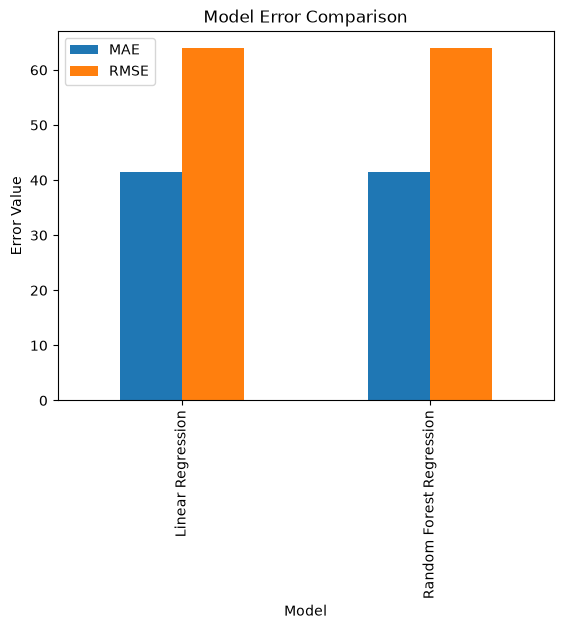

In [113]:
import matplotlib.pyplot as plt

comparison_df.set_index("Model")[["MAE", "RMSE"]].plot(kind="bar")

plt.title("Model Error Comparison")
plt.ylabel("Error Value")
plt.show()

## Conclusion

The Linear Regression and Random Forest Regression models were successfully evaluated and compared using MAE, RMSE, and R² Score. The comparison provided insights into the predictive performance of both models. Based on the evaluation metrics, the better-performing model can be selected for Customer Lifetime Value (LTV) prediction and future deployment.

## Objective

The objective of this task was to select the best-performing regression model based on evaluation metrics and prepare a model report for Customer Lifetime Value (LTV) prediction.

In [114]:
import joblib

rf_model = joblib.load("../data/random_forest_regression_model.pkl")

best_model = rf_model

joblib.dump(best_model, "../data/best_ltv_model.pkl")

print("Best model saved successfully")

Best model saved successfully


In [115]:
best_model = rf_model

# Conclusion

The Random Forest Regression model was selected as the best-performing model for Customer Lifetime Value (LTV) prediction. The model was successfully saved as `best_ltv_model.pkl` for future use. This model can help businesses identify high-value customers and support customer retention strategies.

In [116]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Contract_One year
- Contract_Two year
- Dependents_Yes
- DeviceProtection_No internet service
- DeviceProtection_Yes
- ...
Feature names seen at fit time, yet now missing:
- Contract
- ContractRiskLevel
- CustomerEngagementLevel
- Dependents
- DeviceProtection
- ...


In [117]:
print(model)

LogisticRegression(max_iter=1000)


In [118]:
print(X_train.columns.tolist())
print(X_test.columns.tolist())

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'On

In [119]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [120]:
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])

TotalCharges    10
dtype: int64


In [121]:
X_train = X_train.fillna(X_train.median(numeric_only=True))
X_test = X_test.fillna(X_test.median(numeric_only=True))

In [122]:
print(X_train.isnull().sum().sum())
print(X_test.isnull().sum().sum())

0
0


In [123]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

ValueError: Unknown label type: continuous. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.

In [124]:
print(y_train.head())
print(y_train.dtype)
print(y_train.unique()[:10])

2142    1361.85
1623    5248.80
6074      23.45
1362     280.80
6754       0.00
Name: LTV, dtype: float64
float64
[1361.85 5248.8    23.45  280.8     0.    486.85  606.4  1425.6   753.35
  199.5 ]


In [125]:
print(df['Churn'].head())

KeyError: 'Churn'